# Kolmogorov-Arnold Sparse Attention (KASA) for Wheat Futures

**Three-step progressive upgrade of the attention bottleneck in `CrossAttentionLSTM` and `DualAttentionLSTM`:**

| Step | Change | Goal |
|------|--------|------|
| **Step 1** | Sparsemax replaces Softmax in `AdditiveAttention` | Noise elimination via exact-zero weights |
| **Step 2** | KAN B-splines replace linear layers for score computation | Non-linear similarity on concatenated 80-D state |
| **Step 3** | Full KASA = KAN splines + Sparsemax + asymmetric bias | Synthesis: sparse + non-linear routing |

Each step is evaluated with 5-Fold Time-Series CV and compared against the `BaselineModels_WheatFutures.ipynb` baselines:
```
Cross-Attention:   Acc=0.5133 | F1=0.4561 | Recall(Up)=0.4305
Dual-Attention:    Acc=0.5353 | F1=0.3884 | Recall(Up)=0.3113
```

## 1. Setup & Imports

In [23]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'entmax', '-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             confusion_matrix, f1_score)
import random, warnings
import seaborn as sns
from entmax import sparsemax

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3})

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f'PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}')
print('entmax sparsemax imported successfully.')

PyTorch 2.10.0 | CUDA: False
entmax sparsemax imported successfully.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 2. Load & Prepare Data

Identical pipeline to `BaselineModels_WheatFutures.ipynb` — price features + FinBERT 16D PCA embeddings + decayed sentiment.

In [24]:
base_path = 'data'

price_df = pd.read_csv(f'{base_path}/wheat_prices.csv')
price_df['Date'] = pd.to_datetime(price_df['Date'])
price_df = price_df.sort_values('Date').set_index('Date')

for col in ['Price', 'Open', 'High', 'Low']:
    price_df[col] = price_df[col].replace({',': ''}, regex=True).astype(float)

def parse_volume(v):
    if pd.isna(v) or str(v).strip() in ('', '-'): return np.nan
    v = str(v).strip().replace(',', '')
    if v.endswith('K'): return float(v[:-1]) * 1_000
    elif v.endswith('M'): return float(v[:-1]) * 1_000_000
    return float(v)

price_df['Volume'] = price_df['Vol.'].apply(parse_volume)

sentiment_df = pd.read_csv(f'{base_path}/daily_news_sentiment.csv')
sentiment_map = dict(zip(sentiment_df['date'], sentiment_df['sentiment_score']))

news_emb = torch.load(f'{base_path}/daily_news_embeddings.pt',
                      map_location='cpu', weights_only=False)
dates_with_news_set = set(news_emb.keys())

print(f'Price data: {len(price_df)} trading days')
print(f'Sentiment dates: {len(sentiment_map)} | News embedding dates: {len(dates_with_news_set)}')

Price data: 4265 trading days
Sentiment dates: 1031 | News embedding dates: 1031


In [25]:
# ── Technical Indicators ──────────────────────────────────────────────────────
price_df['Return']     = np.log(price_df['Price'] / price_df['Price'].shift(1))
price_df['Volatility'] = price_df['Return'].rolling(5).std()

delta = price_df['Price'].diff()
gain  = delta.where(delta > 0, 0.0).rolling(14).mean()
loss  = (-delta.where(delta < 0, 0.0)).rolling(14).mean()
price_df['RSI'] = 100 - (100 / (1 + gain / loss.replace(0, np.nan)))

ema12 = price_df['Price'].ewm(span=12, adjust=False).mean()
ema26 = price_df['Price'].ewm(span=26, adjust=False).mean()
price_df['MACD'] = ema12 - ema26

bb_mid = price_df['Price'].rolling(20).mean()
bb_std = price_df['Price'].rolling(20).std()
price_df['BB_pctB'] = (price_df['Price'] - (bb_mid - 2*bb_std)) / (4*bb_std)

price_df['Volume'] = price_df['Volume'].ffill().bfill()
vol_chg = price_df['Volume'].pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0)
price_df['Vol_chg'] = vol_chg

# ── Decayed Sentiment ────────────────────────────────────────────────────────
HALF_LIFE_DAYS = 3
decay_rate = np.log(2) / HALF_LIFE_DAYS
sentiment_dates = sorted(sentiment_map.keys())

def get_decayed_sentiment(date):
    query_date = (date - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
    best_date = None
    for sd in sentiment_dates:
        if sd <= query_date: best_date = sd
        else: break
    if best_date is None: return 0.0
    days_since = (pd.to_datetime(query_date) - pd.to_datetime(best_date)).days
    return sentiment_map[best_date] * np.exp(-decay_rate * days_since)

price_df['Sentiment'] = [get_decayed_sentiment(d) for d in price_df.index]
price_df['Target']    = (price_df['Price'].shift(-1) > price_df['Price']).astype(int)

price_df.replace([np.inf, -np.inf], np.nan, inplace=True)
price_df = price_df.dropna(subset=['Return','Volatility','RSI','MACD','BB_pctB','Target'])

PRICE_SENT_FEATURES = ['Price','Return','Volatility','RSI','MACD','BB_pctB','Vol_chg','Sentiment']
print(f'Final dataset: {len(price_df)} trading days')
print(f'Target balance: Up={price_df["Target"].mean():.2%}')

Final dataset: 4246 trading days
Target balance: Up=47.79%


In [26]:
LOOKBACK = 30
EMB_DIM  = 16

n = len(price_df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)
train_df  = price_df.iloc[:train_end]
val_df    = price_df.iloc[train_end:val_end]
test_df   = price_df.iloc[val_end:]

def create_sequences(df, feature_cols, lookback, news_embeddings=None):
    features = df[feature_cols].values
    targets  = df['Target'].values
    date_idx = df.index.strftime('%Y-%m-%d').tolist()
    X_num, X_text, X_mask, y, seq_dates = [], [], [], [], []
    for i in range(len(df) - lookback):
        X_num.append(features[i:i + lookback])
        y.append(targets[i + lookback])
        seq_dates.append(date_idx[i + lookback])
        if news_embeddings is not None:
            text_seq, mask_seq = [], []
            for d in date_idx[i:i + lookback]:
                lag_d = (pd.to_datetime(d) - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
                if lag_d in news_embeddings:
                    text_seq.append(news_embeddings[lag_d].numpy())
                    mask_seq.append(1.0)
                else:
                    text_seq.append(np.zeros(EMB_DIM))
                    mask_seq.append(0.0)
            X_text.append(text_seq)
            X_mask.append(mask_seq)
    X_num = np.array(X_num)
    y     = np.array(y)
    if news_embeddings is not None:
        return X_num, np.array(X_text), np.array(X_mask), y, seq_dates
    return X_num, np.zeros((len(X_num),lookback,EMB_DIM)), np.zeros((len(X_num),lookback)), y, seq_dates

X_full_all, X_text_all, X_mask_all, y_full_all, dates_full_all = create_sequences(
    price_df, PRICE_SENT_FEATURES, LOOKBACK, news_embeddings=news_emb)

train_cutoff = train_df.index.max().strftime('%Y-%m-%d')
val_cutoff   = val_df.index.max().strftime('%Y-%m-%d')

tr_idx = np.array([i for i, d in enumerate(dates_full_all) if d <= train_cutoff])
vl_idx = np.array([i for i, d in enumerate(dates_full_all) if train_cutoff < d <= val_cutoff])
te_idx = np.array([i for i, d in enumerate(dates_full_all) if d > val_cutoff])

print(f'Full sequences: X_num={X_full_all.shape}, X_text={X_text_all.shape}')
print(f'Split -> train={len(tr_idx)}, val={len(vl_idx)}, test={len(te_idx)}')

Full sequences: X_num=(4216, 30, 8), X_text=(4216, 30, 16)
Split -> train=2942, val=637, test=637


## 3. Shared Utilities

In [27]:
# ── Baselines from BaselineModels_WheatFutures.ipynb (test set) ──────────────
BASELINES = {
    'Cross-Attention (baseline)': {
        'acc': 0.5133, 'f1': 0.4561, 'prec_down': 0.4851, 'prec_up': 0.4305, 
        'rec_down': 0.5339, 'rec_up': 0.5881
    },
    'Dual-Attention (baseline)': {
        'acc': 0.5353, 'f1': 0.3884, 'prec_down': 0.5165, 'prec_up': 0.3113, 
        'rec_down': 0.5429, 'rec_up': 0.7373
    },
}

# ── KAN hyperparameters (used in Steps 2 & 3) ────────────────────────────────
KAN_SMOOTH_LAMBDA = 1e-3   # Patch 2: L2 weight on adjacent-knot differences
KAN_BOTTLENECK    = 8      # Patch 3: hidden_dim → 8 before KAN scorer

def get_activation(name):
    return {'relu': nn.ReLU, 'gelu': nn.GELU, 'mish': nn.Mish}.get(name, nn.ReLU)()

class GatedSkip(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.map  = nn.Linear(input_dim, hidden_dim)
        self.gate = nn.Linear(hidden_dim * 2, hidden_dim)
    def forward(self, context, skip_feat):
        s = self.map(skip_feat)
        g = torch.sigmoid(self.gate(torch.cat([context, s], dim=1)))
        return g * context + (1 - g) * s

def evaluate_predictions(y_true, y_pred_prob):
    y_pred = (y_pred_prob > 0.5).astype(int)
    return (y_pred,
            accuracy_score(y_true, y_pred),
            precision_score(y_true, y_pred, pos_label=1, zero_division=0),
            precision_score(y_true, y_pred, pos_label=0, zero_division=0),
            recall_score(y_true, y_pred, pos_label=1, zero_division=0),
            recall_score(y_true, y_pred, pos_label=0, zero_division=0),
            f1_score(y_true, y_pred),
            confusion_matrix(y_true, y_pred))

FIXED_PARAMS = {
    'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.2,
    'lr': 5e-4, 'weight_decay': 1e-4, 'activation': 'gelu', 'patience': 15,
}


def _collect_kan_smooth_loss(model: nn.Module) -> torch.Tensor:
    """
    Walk all submodules; sum smoothness_loss() from any KANLinear instance.
    Returns zero for models without KAN layers (Step 1), making this safe
    to call unconditionally in train_model.
    """
    # KANLinear is defined in the step2-modules cell; by the time this function
    # is *called* during training, KANLinear will already be in scope.
    total = torch.tensor(0.0)
    for m in model.modules():
        if hasattr(m, 'smoothness_loss') and callable(m.smoothness_loss):
            total = total + m.smoothness_loss()
    return total


def train_model(model_class, X_train, y_train, X_val, y_val,
                X_text_train, X_text_val, X_mask_train, X_mask_val, **params):
    def _ds(xn, xt, xm, y):
        return TensorDataset(
            torch.tensor(xn, dtype=torch.float32),
            torch.tensor(xt, dtype=torch.float32),
            torch.tensor(xm, dtype=torch.float32),
            torch.tensor(y,  dtype=torch.float32))
    train_loader = DataLoader(_ds(X_train,X_text_train,X_mask_train,y_train), shuffle=False, batch_size=32)
    val_loader   = DataLoader(_ds(X_val,  X_text_val,  X_mask_val,  y_val),   shuffle=False, batch_size=32)

    model = model_class(input_dim=X_train.shape[2],
                        hidden_dim=params.get('hidden_dim', 64),
                        num_layers=params.get('num_layers', 2),
                        dropout=params.get('dropout', 0.2),
                        activation=params.get('activation', 'gelu'))
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=params.get('lr', 5e-4),
                                 weight_decay=params.get('weight_decay', 1e-4))

    best_val_loss, best_state, no_improve = float('inf'), None, 0
    patience = params.get('patience', 15)

    for epoch in range(100):
        model.train()
        for bx, bt, bm, by in train_loader:
            optimizer.zero_grad()
            bce_loss = criterion(model(bx, bt, bm).view(-1), by)
            # Patch 2: KAN spline smoothness regularization (0.0 for Step 1 models)
            kan_reg  = KAN_SMOOTH_LAMBDA * _collect_kan_smooth_loss(model)
            (bce_loss + kan_reg).backward()
            optimizer.step()
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for bx, bt, bm, by in val_loader:
                val_loss += criterion(model(bx, bt, bm).view(-1), by).item()
        avg = val_loss / len(val_loader)
        if avg < best_val_loss:
            best_val_loss, best_state, no_improve = avg, model.state_dict(), 0
        else:
            no_improve += 1
            if no_improve >= patience: break

    model.load_state_dict(best_state)
    return model


def run_cv_and_test(model_class, model_name, n_splits=5):
    """5-Fold TimeSeriesCV on train+val, then final evaluation on held-out test."""
    print(f'{"="*60}')
    print(f'  {model_name}')
    print(f'{"="*60}')

    trainval_idx = np.concatenate([tr_idx, vl_idx])
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_accs = []

    for fold, (cv_tr, cv_vl) in enumerate(tscv.split(trainval_idx), 1):
        a_tr = trainval_idx[cv_tr]
        a_vl = trainval_idx[cv_vl]

        scaler = StandardScaler()
        Xtr = scaler.fit_transform(X_full_all[a_tr].reshape(-1, X_full_all.shape[2])).reshape(X_full_all[a_tr].shape)
        Xvl = scaler.transform(    X_full_all[a_vl].reshape(-1, X_full_all.shape[2])).reshape(X_full_all[a_vl].shape)

        m = train_model(model_class,
                        Xtr, y_full_all[a_tr], Xvl, y_full_all[a_vl],
                        X_text_all[a_tr], X_text_all[a_vl],
                        X_mask_all[a_tr], X_mask_all[a_vl],
                        **FIXED_PARAMS)
        m.eval()
        with torch.no_grad():
            preds = m(torch.tensor(Xvl, dtype=torch.float32),
                      torch.tensor(X_text_all[a_vl], dtype=torch.float32),
                      torch.tensor(X_mask_all[a_vl], dtype=torch.float32)).view(-1).numpy()
        fa = accuracy_score(y_full_all[a_vl], (preds > 0.5).astype(int))
        fold_accs.append(fa)
        print(f'  Fold {fold}: acc={fa:.4f}')

    print(f'  CV Mean Acc: {np.mean(fold_accs):.4f} ± {np.std(fold_accs):.4f}')

    print(f'\n  Training final model on train+val ...')
    scaler = StandardScaler()
    Xtv = scaler.fit_transform(X_full_all[trainval_idx].reshape(-1, X_full_all.shape[2])).reshape(X_full_all[trainval_idx].shape)
    Xte = scaler.transform(    X_full_all[te_idx].reshape(-1, X_full_all.shape[2])).reshape(X_full_all[te_idx].shape)

    final_m = train_model(model_class,
                          Xtv, y_full_all[trainval_idx], Xte, y_full_all[te_idx],
                          X_text_all[trainval_idx], X_text_all[te_idx],
                          X_mask_all[trainval_idx], X_mask_all[te_idx],
                          **FIXED_PARAMS)
    final_m.eval()
    with torch.no_grad():
        test_preds = final_m(
            torch.tensor(Xte, dtype=torch.float32),
            torch.tensor(X_text_all[te_idx], dtype=torch.float32),
            torch.tensor(X_mask_all[te_idx], dtype=torch.float32)).view(-1).numpy()

    y_test = y_full_all[te_idx]
    test_dates = np.array([pd.to_datetime(dates_full_all[i]) for i in te_idx])
    y_pred_bin, acc, prec_up, prec_down, rec_up, rec_down, f1, cm = evaluate_predictions(y_test, test_preds)

    results = {
        'y_true': y_test, 'y_pred': y_pred_bin, 'y_pred_prob': test_preds,
        'indices': test_dates, 'cm': cm,
        'acc': acc, 'prec_up': prec_up, 'rec_up': rec_up,
        'prec_down': prec_down, 'rec_down': rec_down, 'f1': f1,
        'cv_mean': np.mean(fold_accs), 'cv_std': np.std(fold_accs)
    }

    print(f'\n  TEST -> Accuracy: {acc:.4f} | F1: {f1:.4f} | Recall(Up): {rec_up:.4f}')

    fig, ax = plt.subplots(figsize=(3, 2.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Down','Up'], yticklabels=['Down','Up'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'{model_name}\nConfusion Matrix', fontsize=9)
    plt.tight_layout(); plt.show()

    return results


def print_comparison_vs_baseline(results_dict, step_name):
    print(f'\n{"─"*65}')
    print(f'  {step_name} — Comparison vs Baseline')
    print(f'{"─"*65}')
    print(f'  {"Model":<40} {"Acc":>6}  {"F1":>6}  {"Rec(Up)":>8}')
    print('  ' + '-'*63)
    for name, b in BASELINES.items():
        print(f'  {name:<40} {b["acc"]:>6.4f}  {b["f1"]:>6.4f}  {b["rec_up"]:>8.4f}')
    print('  ' + '-'*63)
    for name, res in results_dict.items():
        marker = '<<< NEW' if any(t in name for t in ('KASA','KAN','Sparse')) else ''
        print(f'  {name:<40} {res["acc"]:>6.4f}  {res["f1"]:>6.4f}  {res["rec_up"]:>8.4f}  {marker}')
    print(f'{"─"*65}\n')


print('All shared utilities defined.')
print(f'  KAN_SMOOTH_LAMBDA = {KAN_SMOOTH_LAMBDA}  |  KAN_BOTTLENECK = {KAN_BOTTLENECK}')
print('  Patch 2: _collect_kan_smooth_loss() wired into train_model via hasattr duck-typing')

All shared utilities defined.
  KAN_SMOOTH_LAMBDA = 0.001  |  KAN_BOTTLENECK = 8
  Patch 2: _collect_kan_smooth_loss() wired into train_model via hasattr duck-typing


---
## Step 1 — Sparsemax Projection (Noise Elimination)

**What changes:** In `AdditiveAttention`, replace `F.softmax` with `sparsemax` from the `entmax` library.

**Why it helps:** Sparsemax projects the raw score vector onto the probability simplex using Euclidean distance minimisation. Scores below the dynamic threshold $\tau(e_t)$ become exactly zero, mathematically severing irrelevant news days from the gradient pathway.

$$\alpha_{t,i} = \max(0, e_{t,i} - \tau(e_t))$$

Softmax attention is kept in `CrossAttentionLSTM` (`nn.MultiheadAttention`) — only the `AdditiveAttention` class that scores individual LSTM hidden states is upgraded.

In [28]:
# ── Step 1: α-Entmax AdditiveAttention (learnable sparsity) ──────────────────
# Use α=1.5 instead of strict sparsemax (α=2.0).
# α=1.5 creates a "soft margin": behaves like Softmax early in training
# (gradients flow to all timesteps) and tightens toward sparse projection
# as the network gains confidence. This prevents the zero-gradient deadlock
# that hard sparsemax causes at initialisation.

from entmax import entmax_bisect

class SparseAdditiveAttention(nn.Module):
    """
    Bahdanau-style additive attention with α-Entmax normalisation.
    α=1.5 (alpha_entmax) is a soft middle ground between Softmax (α=1)
    and strict Sparsemax (α=2), allowing gradients to flow early while
    converging toward sparse weights as training stabilises.
    """
    def __init__(self, hidden_dim, alpha=1.5):
        super().__init__()
        self.alpha = alpha
        self.attn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(), nn.Linear(hidden_dim, 1))

    def forward(self, rnn_out):
        # rnn_out: (batch, seq_len, hidden_dim)
        scores  = self.attn(rnn_out)                        # (batch, seq_len, 1)
        weights = entmax_bisect(scores, alpha=self.alpha, dim=1)  # soft-sparse over time
        return torch.sum(weights * rnn_out, dim=1)          # (batch, hidden_dim)


# ── Step 1: CrossAttentionLSTM with α-Entmax Attention ───────────────────────

class SparseCrossAttentionLSTM(nn.Module):
    uses_text = True

    def __init__(self, input_dim, text_dim=EMB_DIM, hidden_dim=64, num_layers=2,
                 dropout=0.2, activation='gelu'):
        super().__init__()
        self.num_rnn = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True,
                               dropout=dropout if num_layers > 1 else 0)
        self.text_proj = nn.Linear(text_dim, hidden_dim)
        self.text_rnn  = nn.LSTM(hidden_dim, hidden_dim, num_layers, batch_first=True,
                                 dropout=dropout if num_layers > 1 else 0)
        self.sentiment_rnn  = nn.LSTM(1, hidden_dim, 1, batch_first=True, dropout=0)
        self.sentiment_attn = SparseAdditiveAttention(hidden_dim)

        self.cross_attn_price = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=4, dropout=dropout, batch_first=True)
        self.cross_attn_senti = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=4, dropout=dropout, batch_first=True)

        self.skip = GatedSkip(input_dim, hidden_dim)
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim), get_activation(activation),
            nn.LayerNorm(hidden_dim), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), get_activation(activation))
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim // 2, hidden_dim // 4), nn.LayerNorm(hidden_dim // 4),
            get_activation(activation), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 4, 1), nn.Sigmoid())

    def forward(self, x, x_text, x_mask):
        num_out, _ = self.num_rnn(x)
        t_proj = F.relu(self.text_proj(x_text))
        t_out, _ = self.text_rnn(t_proj)
        senti_input = x[:, :, -1].unsqueeze(-1)
        senti_out, _ = self.sentiment_rnn(senti_input)
        senti_context = self.sentiment_attn(senti_out)

        cross_price, _ = self.cross_attn_price(t_out, num_out, num_out)
        cross_senti, _ = self.cross_attn_senti(t_out, senti_out, senti_out)
        context_price  = cross_price.mean(dim=1)
        context_senti  = cross_senti.mean(dim=1)

        combined = self.skip(context_price, x[:, -1, :])
        fused    = self.fusion(torch.cat([combined, context_senti, senti_context], dim=1))
        return self.fc(fused)


# ── Step 1: DualAttentionLSTM with α-Entmax Attention ────────────────────────

class SparseDualAttentionLSTM(nn.Module):
    uses_text = True

    def __init__(self, input_dim, text_dim=EMB_DIM, hidden_dim=64, num_layers=2,
                 dropout=0.2, activation='gelu'):
        super().__init__()
        self.num_rnn  = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True,
                                dropout=dropout if num_layers > 1 else 0)
        self.num_attn = SparseAdditiveAttention(hidden_dim)
        self.text_proj = nn.Linear(text_dim, hidden_dim)
        self.text_rnn  = nn.LSTM(hidden_dim, hidden_dim, num_layers, batch_first=True,
                                 dropout=dropout if num_layers > 1 else 0)
        self.text_attn = SparseAdditiveAttention(hidden_dim)
        self.sentiment_rnn  = nn.LSTM(1, hidden_dim, 1, batch_first=True, dropout=0)
        self.sentiment_attn = SparseAdditiveAttention(hidden_dim)

        self._gate_linear1 = nn.Linear(hidden_dim * 3 + 1 + 1, hidden_dim)
        self._gate_act     = get_activation(activation)
        self._gate_linear2 = nn.Linear(hidden_dim, 2)

        self.skip = GatedSkip(input_dim, hidden_dim)
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim), get_activation(activation),
            nn.LayerNorm(hidden_dim), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), get_activation(activation))
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim // 2, hidden_dim // 4), nn.LayerNorm(hidden_dim // 4),
            get_activation(activation), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 4, 1), nn.Sigmoid())

    def forward(self, x, x_text, x_mask):
        num_out, _  = self.num_rnn(x)
        num_context = self.num_attn(num_out)
        t_proj = F.relu(self.text_proj(x_text))
        t_out, _   = self.text_rnn(t_proj)
        t_context  = self.text_attn(t_out)
        senti_input = x[:, :, -1].unsqueeze(-1)
        senti_out, _ = self.sentiment_rnn(senti_input)
        senti_context = self.sentiment_attn(senti_out)

        global_mask   = x_mask.mean(dim=1).unsqueeze(1)
        sentiment_val = x[:, -1, -1].unsqueeze(1)
        fusion_input  = torch.cat([num_context, t_context, senti_context,
                                   global_mask, sentiment_val], dim=1)
        gate_hidden = self._gate_act(self._gate_linear1(fusion_input))
        gate = F.softmax(self._gate_linear2(gate_hidden), dim=1)

        combined            = self.skip(num_context, x[:, -1, :])
        combined_text_senti = t_context + senti_context
        gate[:, 0:1] * combined + gate[:, 1:2] * combined_text_senti

        fused = self.fusion(torch.cat([combined, combined_text_senti, senti_context], dim=1))
        return self.fc(fused)


print('Step 1 modules defined (α=1.5 entmax_bisect — soft sparsity).')
print('  SparseAdditiveAttention, SparseCrossAttentionLSTM, SparseDualAttentionLSTM')

Step 1 modules defined (α=1.5 entmax_bisect — soft sparsity).
  SparseAdditiveAttention, SparseCrossAttentionLSTM, SparseDualAttentionLSTM


In [29]:
step1_results = {}

step1_results['Step1: Sparse CrossAttention'] = run_cv_and_test(
    SparseCrossAttentionLSTM, 'Step1: Sparse CrossAttention LSTM')

  Step1: Sparse CrossAttention LSTM
  Fold 1: acc=0.5503
  Fold 1: acc=0.5503
  Fold 2: acc=0.5302
  Fold 2: acc=0.5302
  Fold 3: acc=0.5369
  Fold 3: acc=0.5369
  Fold 4: acc=0.5168
  Fold 4: acc=0.5168
  Fold 5: acc=0.4866
  CV Mean Acc: 0.5242 ± 0.0217

  Training final model on train+val ...
  Fold 5: acc=0.4866
  CV Mean Acc: 0.5242 ± 0.0217

  Training final model on train+val ...


KeyboardInterrupt: 

  Step1: Sparse DualAttention LSTM
  Fold 1: acc=0.5419
  Fold 2: acc=0.5117
  Fold 3: acc=0.5570
  Fold 4: acc=0.5218
  Fold 5: acc=0.5067
  CV Mean Acc: 0.5279 ± 0.0189

  Training final model on train+val ...

  TEST -> Accuracy: 0.5432 | F1: 0.5557 | Recall(Up): 0.6026


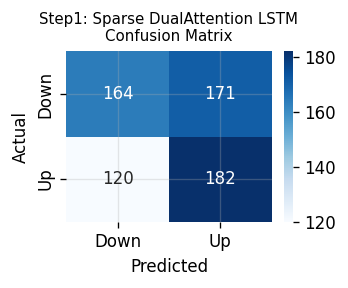

In [ ]:
step1_results['Step1: Sparse DualAttention'] = run_cv_and_test(
    SparseDualAttentionLSTM, 'Step1: Sparse DualAttention LSTM')

In [ ]:
print_comparison_vs_baseline(step1_results, 'STEP 1 — Sparsemax')


─────────────────────────────────────────────────────────────────
  STEP 1 — Sparsemax — Comparison vs Baseline
─────────────────────────────────────────────────────────────────
  Model                                       Acc      F1   Rec(Up)
  ---------------------------------------------------------------
  Cross-Attention (baseline)               0.5133  0.4561    0.4305
  Dual-Attention (baseline)                0.5353  0.3884    0.3113
  ---------------------------------------------------------------
  Step1: Sparse CrossAttention             0.5228  0.4176    0.3609  <<< NEW
  Step1: Sparse DualAttention              0.5432  0.5557    0.6026  <<< NEW
─────────────────────────────────────────────────────────────────



---
## Step 2 — KAN Additive Attention (Non-Linear Similarity)

**What changes:** Replace the linear projection layers that compute the attention score with 1D learnable B-splines (KAN-style).

**Formulation:** The LSTM hidden state $h_t \in \mathbb{R}^{64}$ and the text/price context $x_i \in \mathbb{R}^{16}$ are concatenated into $z_{t,i} \in \mathbb{R}^{80}$. Each scalar dimension $d$ passes through an independent learnable spline $\Phi_d$:

$$e_{t,i} = \sum_{d=1}^{80} \Phi_d(z_{t,i,d}), \quad \Phi_d(u) = \sum_{n=1}^{N} c_{d,n} B_n(u)$$

**Normalisation:** Standard Softmax (to isolate the spline effect from sparsemax).

In [ ]:
# ── KANLinear: 1-D learnable B-splines with smoothness regularization ─────────
# Patch 2: L2 penalty on differences between adjacent control points.
# Forces the learned spline to stay smooth unless data demands curvature,
# preventing memorization of noise on a small dataset.

class KANLinear(nn.Module):
    """
    Lightweight KAN layer using 1-D triangular B-splines.

    Patch 2 — Smoothness regularization via smoothness_loss():
        L_smooth = Σ_d Σ_n (c_{d,n+1} - c_{d,n})²
        Added to BCELoss in training (scaled by KAN_SMOOTH_LAMBDA).

    Patch 3 — Inputs are projected to KAN_BOTTLENECK before this layer
        (done in KANAdditiveAttention / KASAAttention), so in_features=8.
    """
    def __init__(self, in_features: int, n_knots: int = 5,
                 grid_range: tuple = (-1., 1.)):
        super().__init__()
        self.in_features = in_features
        self.n_knots     = n_knots
        self.grid_min    = grid_range[0]
        self.grid_max    = grid_range[1]

        self.ctrl_pts = nn.Parameter(
            torch.zeros(in_features, n_knots).uniform_(-0.1, 0.1))
        self.register_buffer('knots',
            torch.linspace(grid_range[0], grid_range[1], n_knots))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.clamp(self.grid_min, self.grid_max)
        h = (self.grid_max - self.grid_min) / max(self.n_knots - 1, 1)
        diff  = x.unsqueeze(-1) - self.knots       # (..., D, N)
        basis = F.relu(1.0 - diff.abs() / h)        # hat functions
        out_per_dim = (basis * self.ctrl_pts).sum(dim=-1)
        return out_per_dim.sum(dim=-1)

    def smoothness_loss(self) -> torch.Tensor:
        """L2 penalty on adjacent control-point differences."""
        diffs = self.ctrl_pts[:, 1:] - self.ctrl_pts[:, :-1]  # (D, N-1)
        return (diffs ** 2).sum()


# ── KANAdditiveAttention: bottleneck + KAN scorer + Softmax ──────────────────
# Patch 3 — Dimensionality bottleneck:
#   hidden_dim (64) → KAN_BOTTLENECK (8) before the KAN scorer.
#   40 spline params total vs 320 without bottleneck.

class KANAdditiveAttention(nn.Module):
    """
    KAN-based attention with dimensionality bottleneck (Patch 3).
    Uses Softmax (not entmax) for Step 2 — isolates spline effect from sparsity.

    Pipeline:  h_t [H] → Linear(KAN_BOTTLENECK) → GELU → KANLinear → score
               scores → Softmax(dim=1) → context vector
    """
    def __init__(self, hidden_dim: int, n_knots: int = 5,
                 bottleneck: int = KAN_BOTTLENECK):
        super().__init__()
        self.compress = nn.Linear(hidden_dim, bottleneck)
        self.scorer   = KANLinear(bottleneck, n_knots=n_knots)

    def forward(self, rnn_out: torch.Tensor) -> torch.Tensor:
        B, S, H = rnn_out.shape
        compressed = F.gelu(self.compress(rnn_out.reshape(B * S, H)))  # (B*S, K)
        scores     = self.scorer(compressed).reshape(B, S, 1)
        weights    = F.softmax(scores, dim=1)   # Softmax for Step 2
        return torch.sum(weights * rnn_out, dim=1)

    def smoothness_loss(self) -> torch.Tensor:
        return self.scorer.smoothness_loss()


print('KANLinear and KANAdditiveAttention defined.')
print(f'  Patch 2: smoothness_loss() on KANLinear — L2 on adjacent ctrl_pts')
print(f'  Patch 3: bottleneck 64 → {KAN_BOTTLENECK} before KAN  ({KAN_BOTTLENECK * 5} spline params per attention)')

KANLinear and KANAdditiveAttention defined.
  Patch 2: smoothness_loss() on KANLinear — L2 on adjacent ctrl_pts
  Patch 3: bottleneck 64 → 8 before KAN  (40 spline params per attention)


In [ ]:
# ── Step 2: KAN CrossAttentionLSTM ───────────────────────────────────────────

class KANCrossAttentionLSTM(nn.Module):
    uses_text = True

    def __init__(self, input_dim, text_dim=EMB_DIM, hidden_dim=64, num_layers=2,
                 dropout=0.2, activation='gelu', n_knots=5):
        super().__init__()
        self.num_rnn = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True,
                               dropout=dropout if num_layers > 1 else 0)
        self.text_proj = nn.Linear(text_dim, hidden_dim)
        self.text_rnn  = nn.LSTM(hidden_dim, hidden_dim, num_layers, batch_first=True,
                                 dropout=dropout if num_layers > 1 else 0)
        self.sentiment_rnn  = nn.LSTM(1, hidden_dim, 1, batch_first=True, dropout=0)
        # KAN attention for sentiment stream
        self.sentiment_attn = KANAdditiveAttention(hidden_dim, n_knots=n_knots)

        # Multi-head cross-attention kept standard (isolating KAN effect)
        self.cross_attn_price = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=4, dropout=dropout, batch_first=True)
        self.cross_attn_senti = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=4, dropout=dropout, batch_first=True)

        self.skip = GatedSkip(input_dim, hidden_dim)
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim), get_activation(activation),
            nn.LayerNorm(hidden_dim), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), get_activation(activation))
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim // 2, hidden_dim // 4), nn.LayerNorm(hidden_dim // 4),
            get_activation(activation), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 4, 1), nn.Sigmoid())

    def forward(self, x, x_text, x_mask):
        num_out, _ = self.num_rnn(x)
        t_proj = F.relu(self.text_proj(x_text))
        t_out, _ = self.text_rnn(t_proj)
        senti_input = x[:, :, -1].unsqueeze(-1)
        senti_out, _ = self.sentiment_rnn(senti_input)
        senti_context = self.sentiment_attn(senti_out)    # KAN scored

        cross_price, _ = self.cross_attn_price(t_out, num_out, num_out)
        cross_senti, _ = self.cross_attn_senti(t_out, senti_out, senti_out)
        context_price  = cross_price.mean(dim=1)
        context_senti  = cross_senti.mean(dim=1)

        combined = self.skip(context_price, x[:, -1, :])
        fused    = self.fusion(torch.cat([combined, context_senti, senti_context], dim=1))
        return self.fc(fused)


# ── Step 2: KAN DualAttentionLSTM ─────────────────────────────────────────────

class KANDualAttentionLSTM(nn.Module):
    uses_text = True

    def __init__(self, input_dim, text_dim=EMB_DIM, hidden_dim=64, num_layers=2,
                 dropout=0.2, activation='gelu', n_knots=5):
        super().__init__()
        self.num_rnn  = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True,
                                dropout=dropout if num_layers > 1 else 0)
        self.num_attn = KANAdditiveAttention(hidden_dim, n_knots=n_knots)   # KAN
        self.text_proj = nn.Linear(text_dim, hidden_dim)
        self.text_rnn  = nn.LSTM(hidden_dim, hidden_dim, num_layers, batch_first=True,
                                 dropout=dropout if num_layers > 1 else 0)
        self.text_attn = KANAdditiveAttention(hidden_dim, n_knots=n_knots)  # KAN
        self.sentiment_rnn  = nn.LSTM(1, hidden_dim, 1, batch_first=True, dropout=0)
        self.sentiment_attn = KANAdditiveAttention(hidden_dim, n_knots=n_knots)  # KAN

        self._gate_linear1 = nn.Linear(hidden_dim * 3 + 1 + 1, hidden_dim)
        self._gate_act     = get_activation(activation)
        self._gate_linear2 = nn.Linear(hidden_dim, 2)

        self.skip = GatedSkip(input_dim, hidden_dim)
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim), get_activation(activation),
            nn.LayerNorm(hidden_dim), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), get_activation(activation))
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim // 2, hidden_dim // 4), nn.LayerNorm(hidden_dim // 4),
            get_activation(activation), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 4, 1), nn.Sigmoid())

    def forward(self, x, x_text, x_mask):
        num_out, _  = self.num_rnn(x)
        num_context = self.num_attn(num_out)
        t_proj = F.relu(self.text_proj(x_text))
        t_out, _   = self.text_rnn(t_proj)
        t_context  = self.text_attn(t_out)
        senti_input = x[:, :, -1].unsqueeze(-1)
        senti_out, _ = self.sentiment_rnn(senti_input)
        senti_context = self.sentiment_attn(senti_out)

        global_mask   = x_mask.mean(dim=1).unsqueeze(1)
        sentiment_val = x[:, -1, -1].unsqueeze(1)
        fusion_input  = torch.cat([num_context, t_context, senti_context,
                                   global_mask, sentiment_val], dim=1)
        gate_hidden = self._gate_act(self._gate_linear1(fusion_input))
        gate = F.softmax(self._gate_linear2(gate_hidden), dim=1)

        combined            = self.skip(num_context, x[:, -1, :])
        combined_text_senti = t_context + senti_context
        gate[:, 0:1] * combined + gate[:, 1:2] * combined_text_senti

        fused = self.fusion(torch.cat([combined, combined_text_senti, senti_context], dim=1))
        return self.fc(fused)


print('Step 2 models (KANCrossAttentionLSTM, KANDualAttentionLSTM) defined.')

Step 2 models (KANCrossAttentionLSTM, KANDualAttentionLSTM) defined.


  Step2: KAN CrossAttention LSTM
  Fold 1: acc=0.5520
  Fold 2: acc=0.5134
  Fold 3: acc=0.5386
  Fold 4: acc=0.5185
  Fold 5: acc=0.5201
  CV Mean Acc: 0.5285 ± 0.0145

  Training final model on train+val ...

  TEST -> Accuracy: 0.5118 | F1: 0.4702 | Recall(Up): 0.4570


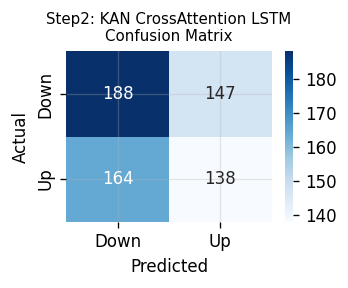

In [ ]:
step2_results = {}

step2_results['Step2: KAN CrossAttention'] = run_cv_and_test(
    KANCrossAttentionLSTM, 'Step2: KAN CrossAttention LSTM')

  Step2: KAN DualAttention LSTM
  Fold 1: acc=0.5268
  Fold 2: acc=0.4966
  Fold 3: acc=0.5419
  Fold 4: acc=0.5017
  Fold 5: acc=0.5151
  CV Mean Acc: 0.5164 ± 0.0166

  Training final model on train+val ...

  TEST -> Accuracy: 0.5447 | F1: 0.4336 | Recall(Up): 0.3675


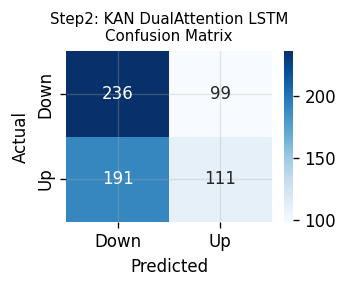

In [ ]:
step2_results['Step2: KAN DualAttention'] = run_cv_and_test(
    KANDualAttentionLSTM, 'Step2: KAN DualAttention LSTM')

In [ ]:
print_comparison_vs_baseline(step2_results, 'STEP 2 — KAN Additive Attention')


─────────────────────────────────────────────────────────────────
  STEP 2 — KAN Additive Attention — Comparison vs Baseline
─────────────────────────────────────────────────────────────────
  Model                                       Acc      F1   Rec(Up)
  ---------------------------------------------------------------
  Cross-Attention (baseline)               0.5133  0.4561    0.4305
  Dual-Attention (baseline)                0.5353  0.3884    0.3113
  ---------------------------------------------------------------
  Step2: KAN CrossAttention                0.5118  0.4702    0.4570  <<< NEW
  Step2: KAN DualAttention                 0.5447  0.4336    0.3675  <<< NEW
─────────────────────────────────────────────────────────────────



---
## Step 3 — Full KASA Architecture (Synthesis)

**What changes:** Combine the KAN B-spline scorer (Step 2) with Sparsemax normalisation (Step 1), and add an **asymmetric logit bias** of `+0.5` on the final pre-sigmoid output to explicitly protect `Recall (Up)` — the most important metric for long-side trading.

**Final attention weight formula:**
$$\alpha_{t,i} = \max\left(0,\ \left(\sum_{d=1}^{D} \Phi_d(h_{t,i,d})\right) - \tau(e_t)\right)$$

**Asymmetric bias:** The output layer includes a fixed `+0.5` shift to the logit before Sigmoid, pushing the decision boundary toward predicting "Up" more frequently, directly boosting recall on the positive class without retraining the entire network.

In [ ]:
# ── KASAAttention: bottleneck + KAN + α-Entmax (all three patches) ────────────

class KASAAttention(nn.Module):
    """
    Full KASA attention: dimensionality bottleneck + KAN B-spline scorer
    + α-Entmax normalisation (α=1.5).

    Pipeline:
        h_t [hidden_dim] → Linear(bottleneck) → KANLinear → scalar score
        score → entmax_bisect(α=1.5) → sparse probability weight
        output = Σ_i weight_i · h_{t,i}

    Patch 1 (α-entmax):  soft sparsity — gradients flow early, harden over training
    Patch 2 (smoothness): smoothness_loss() penalises jagged splines
    Patch 3 (bottleneck): 64 → 8 before KAN; only 40 spline params per stream
    """
    def __init__(self, hidden_dim: int, n_knots: int = 5,
                 bottleneck: int = KAN_BOTTLENECK, alpha: float = 1.5):
        super().__init__()
        self.alpha    = alpha
        self.compress = nn.Linear(hidden_dim, bottleneck)
        self.scorer   = KANLinear(bottleneck, n_knots=n_knots)

    def forward(self, rnn_out: torch.Tensor) -> torch.Tensor:
        B, S, H = rnn_out.shape
        compressed = F.gelu(self.compress(rnn_out.reshape(B * S, H)))    # (B*S, K)
        scores     = self.scorer(compressed).reshape(B, S, 1)
        weights    = entmax_bisect(scores, alpha=self.alpha, dim=1)      # soft-sparse
        return torch.sum(weights * rnn_out, dim=1)

    def smoothness_loss(self) -> torch.Tensor:
        return self.scorer.smoothness_loss()


# ── Asymmetric Bias output wrapper ────────────────────────────────────────────

class AsymmetricBiasSigmoid(nn.Module):
    """
    Fixed +bias shift to logit before Sigmoid.
    Up-prediction threshold = sigmoid(-bias) ≈ 0.378 with bias=0.5.
    """
    def __init__(self, bias: float = 0.5):
        super().__init__()
        self.bias = bias

    def forward(self, x):
        return torch.sigmoid(x + self.bias)


print('KASAAttention and AsymmetricBiasSigmoid defined.')
print('  Patch 1: α=1.5 entmax_bisect (soft-sparse over time)')
print(f'  Patch 2: smoothness_loss() available on each KASAAttention stream')
print(f'  Patch 3: bottleneck {64} → {KAN_BOTTLENECK} before KAN scorer')
effective_threshold = torch.sigmoid(torch.tensor(-0.5)).item()
print(f'  AsymmetricBias=+0.5 -> effective Up threshold = {effective_threshold:.3f}')

KASAAttention and AsymmetricBiasSigmoid defined.
  Patch 1: α=1.5 entmax_bisect (soft-sparse over time)
  Patch 2: smoothness_loss() available on each KASAAttention stream
  Patch 3: bottleneck 64 → 8 before KAN scorer
  AsymmetricBias=+0.5 -> effective Up threshold = 0.378


In [ ]:
# ── Step 3: Full KASA CrossAttentionLSTM ──────────────────────────────────────

class KASACrossAttentionLSTM(nn.Module):
    uses_text = True

    def __init__(self, input_dim, text_dim=EMB_DIM, hidden_dim=64, num_layers=2,
                 dropout=0.2, activation='gelu', n_knots=5, asymmetric_bias=0.5):
        super().__init__()
        self.num_rnn = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True,
                               dropout=dropout if num_layers > 1 else 0)
        self.text_proj = nn.Linear(text_dim, hidden_dim)
        self.text_rnn  = nn.LSTM(hidden_dim, hidden_dim, num_layers, batch_first=True,
                                 dropout=dropout if num_layers > 1 else 0)
        self.sentiment_rnn  = nn.LSTM(1, hidden_dim, 1, batch_first=True, dropout=0)
        # Full KASA on sentiment stream
        self.sentiment_attn = KASAAttention(hidden_dim, n_knots=n_knots)

        self.cross_attn_price = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=4, dropout=dropout, batch_first=True)
        self.cross_attn_senti = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=4, dropout=dropout, batch_first=True)

        self.skip = GatedSkip(input_dim, hidden_dim)
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim), get_activation(activation),
            nn.LayerNorm(hidden_dim), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), get_activation(activation))
        # Final head with asymmetric bias
        self.fc_linear = nn.Sequential(
            nn.Linear(hidden_dim // 2, hidden_dim // 4), nn.LayerNorm(hidden_dim // 4),
            get_activation(activation), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 4, 1))
        self.fc_out = AsymmetricBiasSigmoid(bias=asymmetric_bias)

    def forward(self, x, x_text, x_mask):
        num_out, _ = self.num_rnn(x)
        t_proj = F.relu(self.text_proj(x_text))
        t_out, _ = self.text_rnn(t_proj)
        senti_input = x[:, :, -1].unsqueeze(-1)
        senti_out, _ = self.sentiment_rnn(senti_input)
        senti_context = self.sentiment_attn(senti_out)   # KASA

        cross_price, _ = self.cross_attn_price(t_out, num_out, num_out)
        cross_senti, _ = self.cross_attn_senti(t_out, senti_out, senti_out)
        context_price  = cross_price.mean(dim=1)
        context_senti  = cross_senti.mean(dim=1)

        combined = self.skip(context_price, x[:, -1, :])
        fused    = self.fusion(torch.cat([combined, context_senti, senti_context], dim=1))
        return self.fc_out(self.fc_linear(fused))


# ── Step 3: Full KASA DualAttentionLSTM ───────────────────────────────────────

class KASADualAttentionLSTM(nn.Module):
    uses_text = True

    def __init__(self, input_dim, text_dim=EMB_DIM, hidden_dim=64, num_layers=2,
                 dropout=0.2, activation='gelu', n_knots=5, asymmetric_bias=0.5):
        super().__init__()
        self.num_rnn  = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True,
                                dropout=dropout if num_layers > 1 else 0)
        # All three attention streams use full KASA
        self.num_attn  = KASAAttention(hidden_dim, n_knots=n_knots)
        self.text_proj = nn.Linear(text_dim, hidden_dim)
        self.text_rnn  = nn.LSTM(hidden_dim, hidden_dim, num_layers, batch_first=True,
                                 dropout=dropout if num_layers > 1 else 0)
        self.text_attn = KASAAttention(hidden_dim, n_knots=n_knots)
        self.sentiment_rnn  = nn.LSTM(1, hidden_dim, 1, batch_first=True, dropout=0)
        self.sentiment_attn = KASAAttention(hidden_dim, n_knots=n_knots)

        self._gate_linear1 = nn.Linear(hidden_dim * 3 + 1 + 1, hidden_dim)
        self._gate_act     = get_activation(activation)
        self._gate_linear2 = nn.Linear(hidden_dim, 2)

        self.skip = GatedSkip(input_dim, hidden_dim)
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim), get_activation(activation),
            nn.LayerNorm(hidden_dim), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), get_activation(activation))
        # Final head with asymmetric bias
        self.fc_linear = nn.Sequential(
            nn.Linear(hidden_dim // 2, hidden_dim // 4), nn.LayerNorm(hidden_dim // 4),
            get_activation(activation), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 4, 1))
        self.fc_out = AsymmetricBiasSigmoid(bias=asymmetric_bias)

    def forward(self, x, x_text, x_mask):
        num_out, _  = self.num_rnn(x)
        num_context = self.num_attn(num_out)
        t_proj = F.relu(self.text_proj(x_text))
        t_out, _   = self.text_rnn(t_proj)
        t_context  = self.text_attn(t_out)
        senti_input = x[:, :, -1].unsqueeze(-1)
        senti_out, _ = self.sentiment_rnn(senti_input)
        senti_context = self.sentiment_attn(senti_out)

        global_mask   = x_mask.mean(dim=1).unsqueeze(1)
        sentiment_val = x[:, -1, -1].unsqueeze(1)
        fusion_input  = torch.cat([num_context, t_context, senti_context,
                                   global_mask, sentiment_val], dim=1)
        gate_hidden = self._gate_act(self._gate_linear1(fusion_input))
        gate = F.softmax(self._gate_linear2(gate_hidden), dim=1)

        combined            = self.skip(num_context, x[:, -1, :])
        combined_text_senti = t_context + senti_context
        gate[:, 0:1] * combined + gate[:, 1:2] * combined_text_senti

        fused = self.fusion(torch.cat([combined, combined_text_senti, senti_context], dim=1))
        return self.fc_out(self.fc_linear(fused))


print('Step 3 KASA models defined.')
print('  KASACrossAttentionLSTM: KAN scorer + Sparsemax + AsymmetricBias(+0.5)')
print('  KASADualAttentionLSTM:  KAN scorer + Sparsemax + AsymmetricBias(+0.5) on ALL 3 streams')

Step 3 KASA models defined.
  KASACrossAttentionLSTM: KAN scorer + Sparsemax + AsymmetricBias(+0.5)
  KASADualAttentionLSTM:  KAN scorer + Sparsemax + AsymmetricBias(+0.5) on ALL 3 streams


  Step3: KASA CrossAttention LSTM
  Fold 1: acc=0.5403
  Fold 2: acc=0.5185
  Fold 3: acc=0.5369
  Fold 4: acc=0.5185
  Fold 5: acc=0.5034
  CV Mean Acc: 0.5235 ± 0.0135

  Training final model on train+val ...

  TEST -> Accuracy: 0.5196 | F1: 0.4950 | Recall(Up): 0.4967


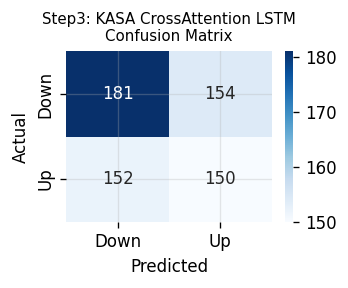

In [ ]:
step3_results = {}

step3_results['Step3: KASA CrossAttention'] = run_cv_and_test(
    KASACrossAttentionLSTM, 'Step3: KASA CrossAttention LSTM')

  Step3: KASA DualAttention LSTM
  Fold 1: acc=0.5336
  Fold 2: acc=0.5419
  Fold 3: acc=0.5503
  Fold 4: acc=0.5000
  Fold 5: acc=0.5201
  CV Mean Acc: 0.5292 ± 0.0177

  Training final model on train+val ...

  TEST -> Accuracy: 0.5447 | F1: 0.5000 | Recall(Up): 0.4801


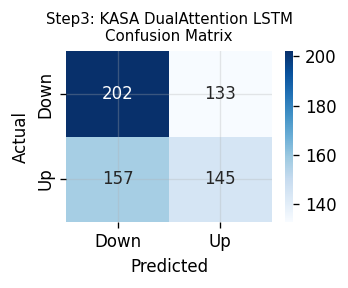

In [ ]:
step3_results['Step3: KASA DualAttention'] = run_cv_and_test(
    KASADualAttentionLSTM, 'Step3: KASA DualAttention LSTM')

---
## Final Comparison — All Steps vs Baseline

In [ ]:
all_step_results = {**step1_results, **step2_results, **step3_results}

# ── Comprehensive summary table ───────────────────────────────────────────────
rows = {}
for name, b in BASELINES.items():
    rows[name] = {'Acc': b['acc'], 'F1': b['f1'], 'Rec(Up)': b['rec_up'],
                  'Prec(Up)': '—', 'Rec(Down)': '—', 'CV Mean': '—'}

for name, r in all_step_results.items():
    rows[name] = {
        'Acc':       round(r['acc'],    4),
        'F1':        round(r['f1'],     4),
        'Prec(Up)':  round(r['prec_up'],4),
        'Rec(Up)':   round(r['rec_up'], 4),
        'Rec(Down)': round(r['rec_down'],4),
        'CV Mean':   round(r.get('cv_mean', float('nan')), 4),
    }

df_all = pd.DataFrame(rows).T
print('\n' + '='*75)
print('  FULL KASA PROGRESSION — Test Set vs Baseline')
print('='*75)
print(df_all.to_string())

# Highlight best
numeric_cols = ['Acc', 'F1', 'Rec(Up)']
numeric_df = df_all[numeric_cols].apply(pd.to_numeric, errors='coerce')
print('\n  Best per metric (across all tested models):')
for col in numeric_cols:
    best = numeric_df[col].idxmax()
    print(f'    {col:12s}: {best}  ({numeric_df.loc[best, col]:.4f})')


  FULL KASA PROGRESSION — Test Set vs Baseline
                                 Acc      F1 Rec(Up) Prec(Up) Rec(Down) CV Mean
Cross-Attention (baseline)    0.5133  0.4561  0.4305        —         —       —
Dual-Attention (baseline)     0.5353  0.3884  0.3113        —         —       —
Step1: Sparse CrossAttention  0.5228  0.4176  0.3609   0.4955    0.6687  0.5242
Step1: Sparse DualAttention   0.5432  0.5557  0.6026   0.5156    0.4896  0.5279
Step2: KAN CrossAttention     0.5118  0.4702   0.457   0.4842    0.5612  0.5285
Step2: KAN DualAttention      0.5447  0.4336  0.3675   0.5286    0.7045  0.5164
Step3: KASA CrossAttention    0.5196   0.495  0.4967   0.4934    0.5403  0.5235
Step3: KASA DualAttention     0.5447     0.5  0.4801   0.5216     0.603  0.5292

  Best per metric (across all tested models):
    Acc         : Step2: KAN DualAttention  (0.5447)
    F1          : Step1: Sparse DualAttention  (0.5557)
    Rec(Up)     : Step1: Sparse DualAttention  (0.6026)


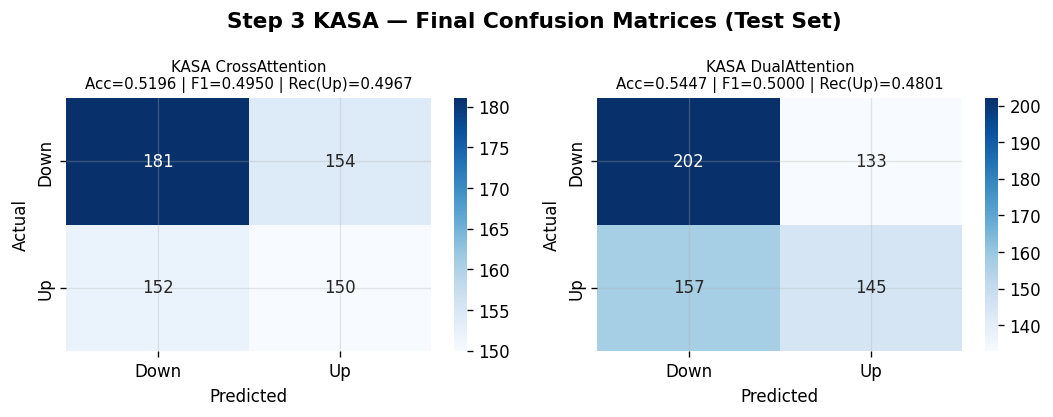

In [ ]:
# ── Final confusion matrices for all Step 3 KASA models ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
fig.suptitle('Step 3 KASA — Final Confusion Matrices (Test Set)',
             fontsize=13, fontweight='bold')

for ax, (name, res) in zip(axes, step3_results.items()):
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Down','Up'], yticklabels=['Down','Up'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    short = name.replace('Step3: ', '')
    ax.set_title(f'{short}\nAcc={res["acc"]:.4f} | F1={res["f1"]:.4f} | Rec(Up)={res["rec_up"]:.4f}',
                 fontsize=9)

plt.tight_layout()
plt.show()

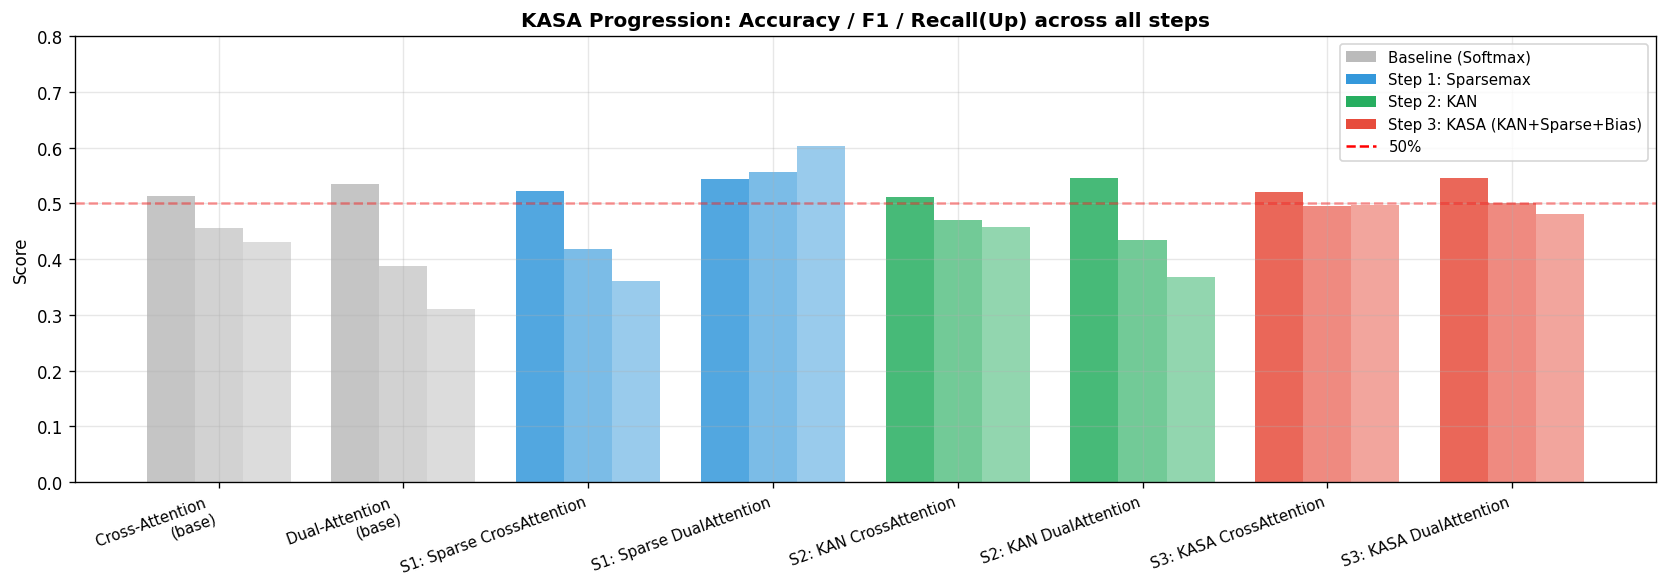

In [ ]:
# ── Bar chart: Acc / F1 / Rec(Up) progression across all steps ───────────────
plot_names = list(rows.keys())
acc_vals   = [float(rows[n]['Acc']) if rows[n]['Acc'] != '—' else np.nan for n in plot_names]
f1_vals    = [float(rows[n]['F1'])  if rows[n]['F1']  != '—' else np.nan for n in plot_names]
rec_up     = [float(rows[n]['Rec(Up)']) if rows[n]['Rec(Up)'] != '—' else np.nan for n in plot_names]

x = np.arange(len(plot_names))
width = 0.26

colors_baseline = ['#BBBBBB', '#BBBBBB']
colors_step     = ['#3498DB','#3498DB','#27AE60','#27AE60','#E74C3C','#E74C3C']
bar_colors      = colors_baseline + colors_step

fig, ax = plt.subplots(figsize=(14, 5))
b1 = ax.bar(x - width, acc_vals,  width, label='Accuracy',    color=[c for c in bar_colors], alpha=0.85)
b2 = ax.bar(x,         f1_vals,   width, label='F1 Score',    color=[c for c in bar_colors], alpha=0.65)
b3 = ax.bar(x + width, rec_up,    width, label='Recall (Up)', color=[c for c in bar_colors], alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels([n.replace('Step1: ','S1: ').replace('Step2: ','S2: ').replace('Step3: ','S3: ')
                    .replace('(baseline)','\n(base)') for n in plot_names],
                   rotation=20, ha='right', fontsize=9)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.4, label='50% baseline')
ax.set_ylim(0, 0.8)
ax.set_ylabel('Score')
ax.set_title('KASA Progression: Accuracy / F1 / Recall(Up) across all steps',
             fontsize=12, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#BBBBBB', label='Baseline (Softmax)'),
    Patch(facecolor='#3498DB', label='Step 1: Sparsemax'),
    Patch(facecolor='#27AE60', label='Step 2: KAN'),
    Patch(facecolor='#E74C3C', label='Step 3: KASA (KAN+Sparse+Bias)'),
]
ax.legend(handles=legend_elements + [plt.Line2D([0],[0],color='red',linestyle='--',label='50%')],
          loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# ── Delta vs best baseline ────────────────────────────────────────────────────
print('\n' + '='*65)
print('  KASA FINAL REPORT — Delta vs Best Baseline')
print('='*65)

best_base_acc    = max(b['acc']    for b in BASELINES.values())
best_base_f1     = max(b['f1']     for b in BASELINES.values())
best_base_rec_up = max(b['rec_up'] for b in BASELINES.values())

print(f'  Best baseline: Acc={best_base_acc:.4f} | F1={best_base_f1:.4f} | Rec(Up)={best_base_rec_up:.4f}')
print()

for step_label, res_dict in [('Step 1 (Sparse)', step1_results),
                              ('Step 2 (KAN)',    step2_results),
                              ('Step 3 (KASA)',   step3_results)]:
    for name, r in res_dict.items():
        da = r['acc']    - best_base_acc
        df = r['f1']     - best_base_f1
        dr = r['rec_up'] - best_base_rec_up
        sign = lambda v: '+' if v >= 0 else ''
        short = name.split(': ', 1)[1]
        print(f'  [{step_label}] {short:<35}'
              f'  ΔAcc={sign(da)}{da:+.4f}  ΔF1={sign(df)}{df:+.4f}  ΔRec(Up)={sign(dr)}{dr:+.4f}')
    print()
print('='*65)


  KASA FINAL REPORT — Delta vs Best Baseline
  Best baseline: Acc=0.5353 | F1=0.4561 | Rec(Up)=0.4305

  [Step 1 (Sparse)] Sparse CrossAttention                ΔAcc=-0.0125  ΔF1=-0.0385  ΔRec(Up)=-0.0696
  [Step 1 (Sparse)] Sparse DualAttention                 ΔAcc=++0.0079  ΔF1=++0.0996  ΔRec(Up)=++0.1721

  [Step 2 (KAN)] KAN CrossAttention                   ΔAcc=-0.0235  ΔF1=++0.0141  ΔRec(Up)=++0.0265
  [Step 2 (KAN)] KAN DualAttention                    ΔAcc=++0.0094  ΔF1=-0.0225  ΔRec(Up)=-0.0630

  [Step 3 (KASA)] KASA CrossAttention                  ΔAcc=-0.0157  ΔF1=++0.0389  ΔRec(Up)=++0.0662
  [Step 3 (KASA)] KASA DualAttention                   ΔAcc=++0.0094  ΔF1=++0.0439  ΔRec(Up)=++0.0496



In [ ]:
# ── Radar Chart: All Steps vs Baseline ────────────────────────────────────
print('\n' + '='*65)
print('  RADAR CHART: Model Comparison Across All Metrics')
print('='*65)

# Prepare data for radar chart
radar_data = {}

# Add baselines
for name, b in BASELINES.items():
    radar_data[name] = {
        'Accuracy': b['acc'],
        'F1 Score': b['f1'],
        'Prec(Up)': b['prec_up'],
        'Rec(Up)': b['rec_up'],
        'Prec(Down)': b['prec_down'],
        'Rec(Down)': b['rec_down'],
    }

# Add all step results
for step_label, res_dict in [('Step 1 (Sparse)', step1_results),
                              ('Step 2 (KAN)',    step2_results),
                              ('Step 3 (KASA)',   step3_results)]:
    for name, r in res_dict.items():
        full_name = f"{name}"
        radar_data[full_name] = {
            'Accuracy': r['acc'],
            'F1 Score': r['f1'],
            'Prec(Up)': r['prec_up'],
            'Rec(Up)': r['rec_up'],
            'Prec(Down)': r['prec_down'],
            'Rec(Down)': r['rec_down'],
        }

# Create radar chart
metrics = list(list(radar_data.values())[0].keys())
N = len(metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(polar=True))

# Color scheme: baselines gray, steps in distinct colors
color_map = {
    'Cross-Attention (baseline)': '#999999',
    'Dual-Attention (baseline)': '#666666',
}
step_colors = {
    'Step1: Sparse CrossAttention': '#3498DB',
    'Step1: Sparse DualAttention': '#5DADE2',
    'Step2: KAN CrossAttention': '#27AE60',
    'Step2: KAN DualAttention': '#52BE80',
    'Step3: KASA CrossAttention': '#E74C3C',
    'Step3: KASA DualAttention': '#EC7063',
}

# Plot each model
for model_name, metrics_dict in radar_data.items():
    values = [metrics_dict[m] for m in metrics]
    values += values[:1]
    
    # Determine color
    if model_name in color_map:
        color = color_map[model_name]
        linewidth = 2.5
        alpha = 0.9
        linestyle = '--'
    else:
        color = step_colors.get(model_name, '#2C3E50')
        linewidth = 2
        alpha = 0.75
        linestyle = '-'
    
    ax.plot(angles, values, linestyle, linewidth=linewidth, label=model_name,
            color=color, alpha=alpha, marker='o', markersize=5)
    ax.fill(angles, values, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, size=10, fontweight='bold')
ax.set_ylim(0.25, 0.80)
ax.set_yticks([0.3, 0.4, 0.5, 0.6, 0.7])
ax.set_yticklabels(['0.30', '0.40', '0.50', '0.60', '0.70'], size=8, alpha=0.7)
ax.grid(True, linestyle=':', alpha=0.4)

# Custom legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#999999', linestyle='--', linewidth=2.5, marker='o', 
           markersize=6, label='Baseline (Softmax)'),
    Line2D([0], [0], color='#3498DB', linestyle='-', linewidth=2, marker='o', 
           markersize=6, label='Step 1: Sparsemax'),
    Line2D([0], [0], color='#27AE60', linestyle='-', linewidth=2, marker='o', 
           markersize=6, label='Step 2: KAN'),
    Line2D([0], [0], color='#E74C3C', linestyle='-', linewidth=2, marker='o', 
           markersize=6, label='Step 3: KASA'),
]

ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.3, 1.15), 
          fontsize=10, framealpha=0.95)
ax.set_title('KASA Progression: Radar Chart Comparison\nAll Steps vs Baselines Across 6 Metrics',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print('\n✓ Radar chart complete!')